#Exercise 4: NumPy Array Operations (20 points)
Complete the following tasks using NumPy.

In [39]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
array=np.ones((5,5))
array[1:4,1:4]=0
print(array)

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat=np.linalg.inv(X.T@X)@X.T@y
print(theta_hat)
print(true_theta)
difference=theta_hat-true_theta
print(f"Difference from true theta:{difference}")
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[ 2.51723721 -1.19783796  3.72399266]
[ 2.5 -1.2  3.7]
Difference from true theta:[0.01723721 0.00216204 0.02399266]


#Exercise 5: Pandas Data Analysis (30 points)
Analyze a dataset of student performance.

In [40]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
missing=df.isnull().sum()
print(f"Missing values:{missing.values}")
print(f"Null sum:{missing.values.sum()}")
df_meanmaj=df.groupby('major')['exam_score'].mean()
df['exam_score']=df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)
df['hours_studied']=df['hours_studied'].fillna(df['year'].median())
print(df['exam_score'].isnull().sum())
print(df['hours_studied'].isnull().sum())

# Task 2: Analysis (10 points)
print(f"Average scores for each major:{df_meanmaj}")
print(f"Major with the highest average score:{max(df_meanmaj.values)}")
data1={
    'hours_studied':df['hours_studied'],
    'exam_score':df['exam_score']
}
df1=pd.DataFrame(data1)
corrl=df1.corr()
print("Correlation between hours studied and exam score:")
print(corrl)

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
# Adding new columns
df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0, 70, 80, 90, 100],
    labels=['Needs Improvement', 'Average', 'Good', 'Excellent'],
    include_lowest=True
)
# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
# 1. Re-group
holder = df.groupby(['major', 'year'])

# 2. Use a lambda function to build the lists.
# This completely bypasses the global 'list' keyword conflict!
result = holder['exam_score'].agg(lambda x: [item for item in x])
reslist = result.tolist()

# 3. Your search loops—safely using 'sublist' so it NEVER ruins the environment again
for a in range(5):
    highest = -1
    highest_list_idx = None
    highest_item_idx = None

    for list_idx, sublist in enumerate(reslist):
        for i in range(len(sublist)):
            if sublist[i] > highest:
                highest = sublist[i]
                highest_list_idx = list_idx
                highest_item_idx = i

    if highest_list_idx is not None:
        reslist[highest_list_idx].pop(highest_item_idx)
        print(f"The number {a+1} highest score is {highest:.2f}!")

Missing values:[ 0  0  0 10  0  5]
Null sum:15
0
0
Average scores for each major:major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Major with the highest average score:76.4251838797971
Correlation between hours studied and exam score:
               hours_studied  exam_score
hours_studied       1.000000   -0.032105
exam_score         -0.032105    1.000000
The number 1 highest score is 100.00!
The number 2 highest score is 100.00!
The number 3 highest score is 98.15!
The number 4 highest score is 96.44!
The number 5 highest score is 96.33!


#Exercise 6: Data Visualization (25 points)
Create meaningful visualizations using the dataset from Exercise 5.

/tmp/ipykernel_1991/2801891458.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_1991/2801891458.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


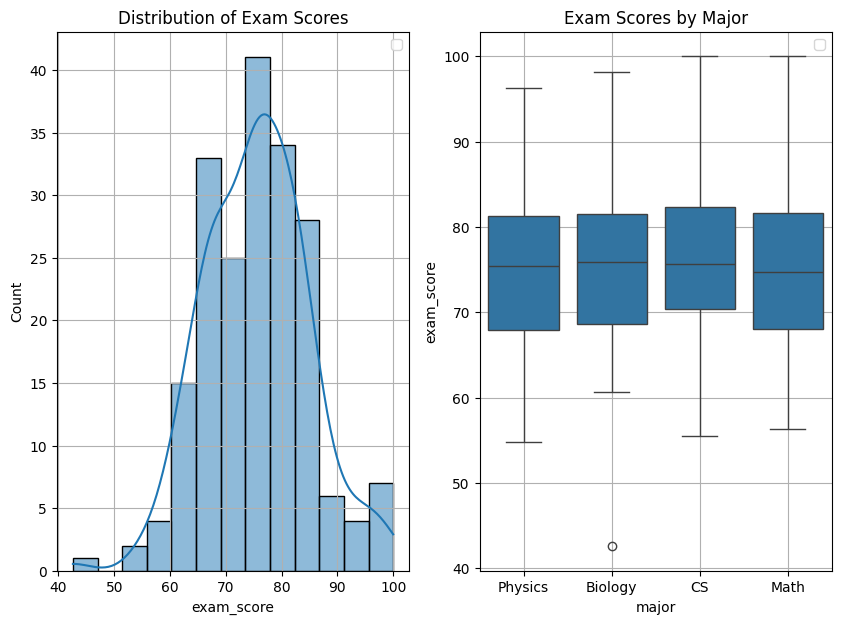

/tmp/ipykernel_1991/2801891458.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


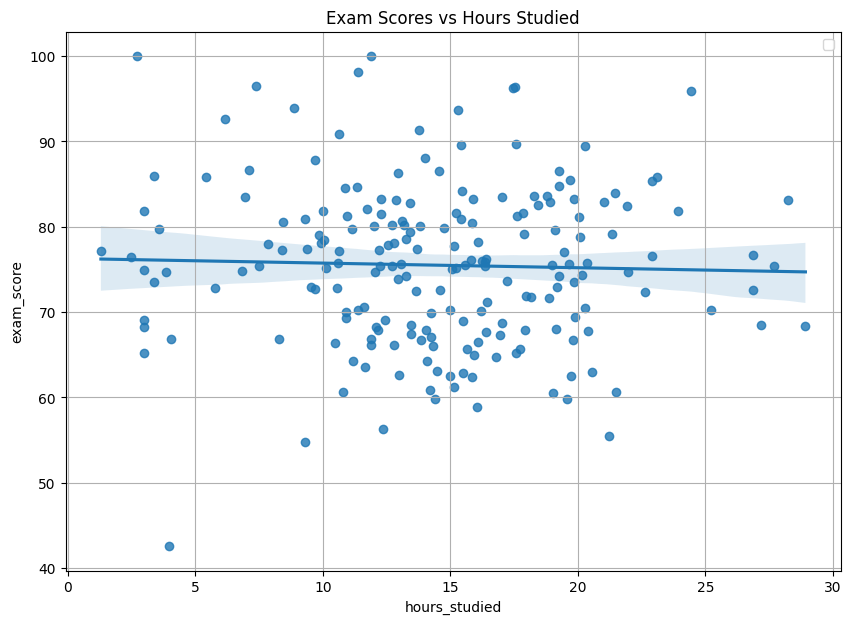

/tmp/ipykernel_1991/2801891458.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,0].legend()
/tmp/ipykernel_1991/2801891458.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()
/tmp/ipykernel_1991/2801891458.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()
/tmp/ipykernel_1991/2801891458.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,1].legend()


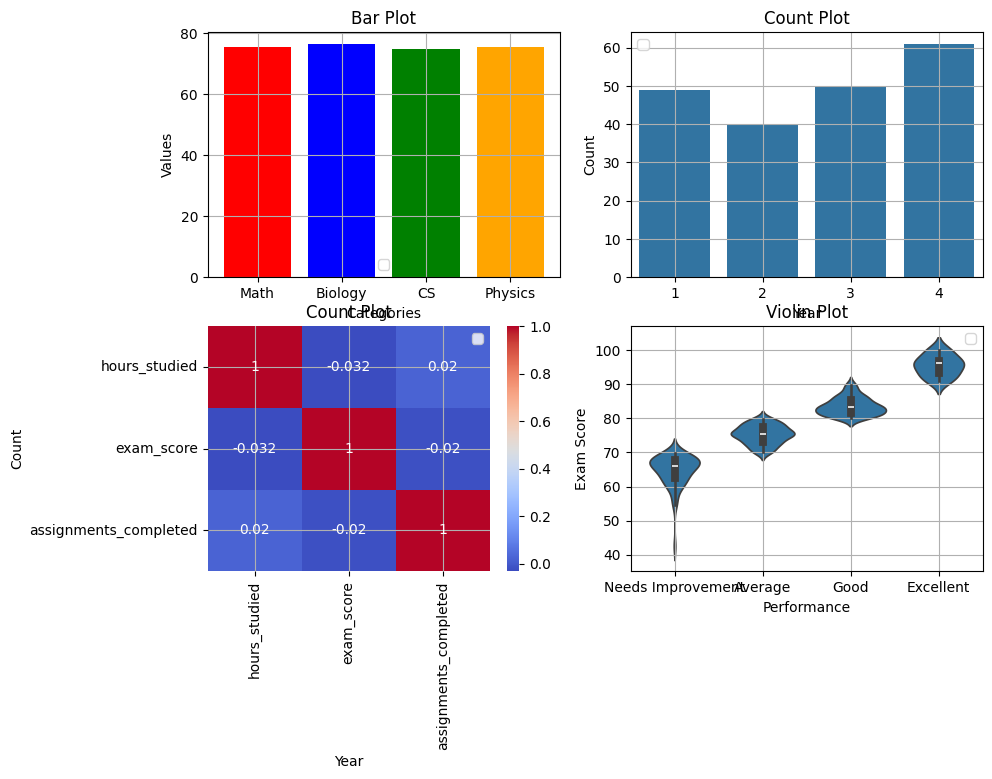

In [57]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
fig,ax=plt.subplots(1,2,figsize=(10,7))
sns.histplot(data=df,x='exam_score',kde=True,ax=ax[0])
sns.boxplot(data=df,x='major',y='exam_score',ax=ax[1])
ax[0].set_title('Distribution of Exam Scores')
ax[1].set_title('Exam Scores by Major')
ax[0].legend()
ax[1].legend()
ax[0].grid(True)
ax[1].grid(True)
plt.show()

# Task 2: Relationship Visualization (8 points)
fig,ax=plt.subplots(figsize=(10,7))
# Scatter with regression line
sns.regplot(data=df, x='hours_studied', y='exam_score',ax=ax)
ax.set_title('Exam Scores vs Hours Studied')
ax.legend()
ax.grid(True)
plt.show()

# Task 3: Advanced Dashboard (9 points)
fig,ax=plt.subplots(2,2,figsize=(10,7))

# Bar plot
categories = ['Math', 'Biology', 'CS', 'Physics']
values = df_meanmaj.values
ax[0,0].bar(categories, values, color=['red', 'blue', 'green', 'orange'])
ax[0,0].set_xlabel('Categories')
ax[0,0].set_ylabel('Values')
ax[0,0].set_title('Bar Plot')
ax[0,0].grid(True)
ax[0,0].legend()
# Count plot
# Create a count plot for the 'day' column
sns.countplot(data=df, x='year',ax=ax[0,1])
ax[0,1].set_xlabel('Year')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Count Plot')
ax[0,1].grid(True)
ax[0,1].legend()

# Correlation heatmap
data2={
    'hours_studied':df['hours_studied'],
    'exam_score':df['exam_score'],
    'assignments_completed':df['assignments_completed']
}
pdf2=pd.DataFrame(data2)
correlation = pdf2.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',ax=ax[1,0])
ax[1,0].set_xlabel('Year')
ax[1,0].set_ylabel('Count')
ax[1,0].set_title('Count Plot')
ax[1,0].grid(True)
ax[1,0].legend()

# Violin plot
sns.violinplot(df,x='performance',y='exam_score',ax=ax[1,1])
ax[1,1].set_xlabel('Performance')
ax[1,1].set_ylabel('Exam Score')
ax[1,1].set_title('Violin Plot')
ax[1,1].grid(True)
ax[1,1].legend()
plt.show()
# TODO: Create a 2x2 subplot figure containing:
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability


#Exercise 7: Integration Challenge (25 points)
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.

Teens(18-25):
Number of customers:81
Average income:50634.01832958778
Average CLV:927.5989606455249
Total CLV:75135.51581228751

Young adults(26-35):
Number of customers:73
Average income:48747.1480463368
Average CLV:955.8721923676795
Total CLV:69778.6700428406

Adults(36-50):
Number of customers:160
Average income:48516.895668261546
Average CLV:948.3724229969199
Total CLV:151739.58767950718

Seniors(51-70):
Number of customers:186
Average income:50713.16338354946
Average CLV:994.0533820450493
Total CLV:184893.92906037916

Top 10% of customers:
     age        income  purchase_frequency  avg_purchase_value          CLV
303   52  41762.460678                  12          124.223342  2837.360197
456   32  15000.000000                  11          115.676858  2423.890868
426   42  68713.567863                   8          154.285448  2404.567161
386   63  24200.782005                   9          136.030443  2367.547971
320   52  56538.547475                   9          133.087832  2314.

/tmp/ipykernel_1991/1699642955.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1991/1699642955.py:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


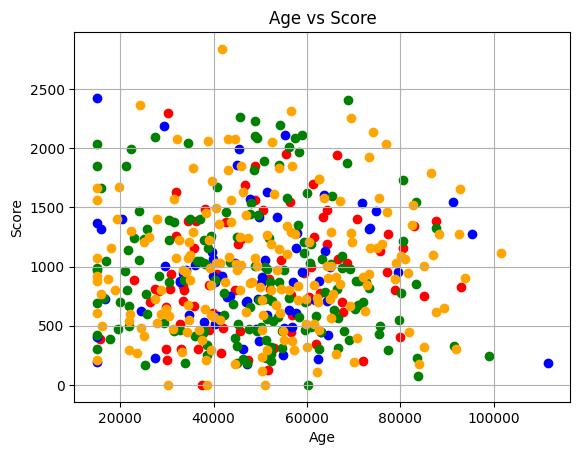

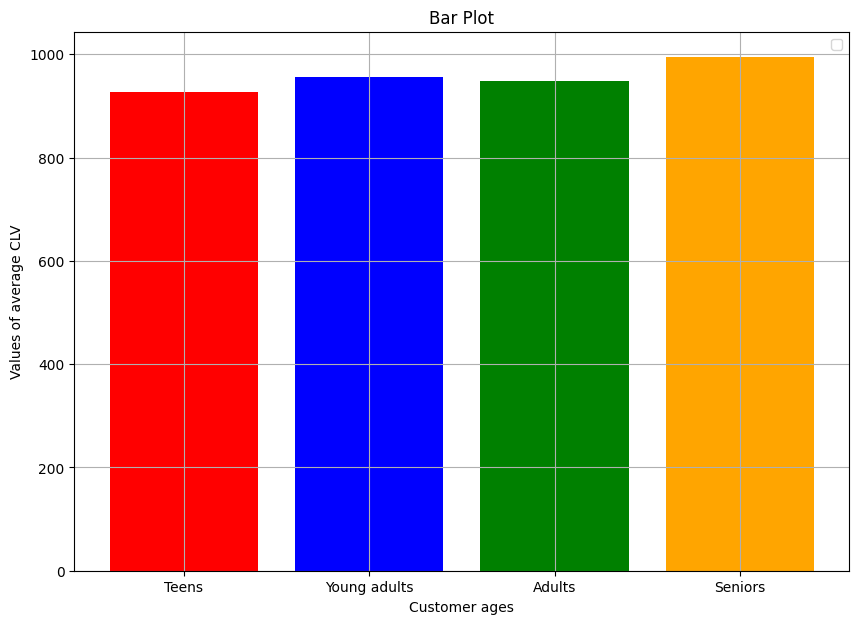

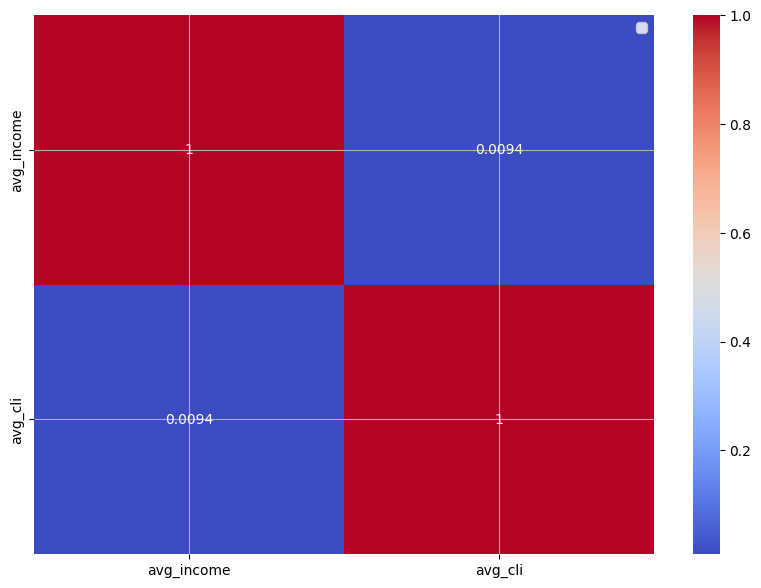

In [62]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
max_freq=purchase_freq.max()
max_frequency=max_freq+1
churn_risk = 1 - (purchase_freq / max_frequency)
CLV = purchase_freq * avg_purchase_value * (1 + churn_risk)

customers['CLV']=customers['purchase_frequency']*customers['avg_purchase_value']*(1+(1-customers['purchase_frequency']/customers['avg_purchase_value']))
# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
teens=customers[(customers['age']>=18) & (customers['age']<=25)]
young_adults=customers[(customers['age']>=26) & (customers['age']<=35)]
adults=customers[(customers['age']>=36) & (customers['age']<=50)]
seniors=customers[(customers['age']>=51) & (customers['age']<=70)]
div_custs=[teens,young_adults,adults,seniors]
# TODO: For each age group, calculate:
print("Teens(18-25):")
print(f"Number of customers:{len(teens)}")
print(f"Average income:{teens['income'].mean()}")
print(f"Average CLV:{teens['CLV'].mean()}")
print(f"Total CLV:{teens['CLV'].sum()}")
print()
print("Young adults(26-35):")
print(f"Number of customers:{len(young_adults)}")
print(f"Average income:{young_adults['income'].mean()}")
print(f"Average CLV:{young_adults['CLV'].mean()}")
print(f"Total CLV:{young_adults['CLV'].sum()}")
print()
print("Adults(36-50):")
print(f"Number of customers:{len(adults)}")
print(f"Average income:{adults['income'].mean()}")
print(f"Average CLV:{adults['CLV'].mean()}")
print(f"Total CLV:{adults['CLV'].sum()}")
print()
print("Seniors(51-70):")
print(f"Number of customers:{len(seniors)}")
print(f"Average income:{seniors['income'].mean()}")
print(f"Average CLV:{seniors['CLV'].mean()}")
print(f"Total CLV:{seniors['CLV'].sum()}")
# TODO: Identify top 10% of customers by CLV
print()
print("Top 10% of customers:")
top10=customers.sort_values('CLV',ascending=False).head(int(len(customers)*0.1))
print(top10)
# TODO: Create visualizations:

# Scatter plot
colors={'red':div_custs[0],'blue':div_custs[1],'green':div_custs[2],'orange':div_custs[3]}
for k,v in colors.items():
    subset=v
    plt.scatter(subset['income'],subset['CLV'],label=v,color=k)
    plt.xlabel('Age')
    plt.ylabel('Score')
    plt.title('Age vs Score')
plt.grid(True)

# Bar chart of average CLV by age group
segs=["Teens","Young adults","Adults","Seniors"]
values = [teens['CLV'].mean(),young_adults['CLV'].mean(),adults['CLV'].mean(),seniors['CLV'].mean()]
fig,ax=plt.subplots(figsize=(10,7))
plt.bar(segs, values, color=['red', 'blue', 'green', 'orange'])
ax.set_xlabel('Customer ages')
ax.set_ylabel('Values of average CLV')
ax.set_title('Bar Plot')
ax.grid(True)
ax.legend()

# Correlation heatmap
corel={
    'avg_income':customers['income'],
    'avg_cli':customers['CLV']
}
tips=pd.DataFrame(corel)
correlation = tips.corr()
fig,ax=plt.subplots(figsize=(10,7))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
ax.grid(True)
ax.legend()

__TODO: Write a brief analysis paragraph (as a markdown cell)__<br>
__summarizing key findings and recommendations__<br>
I found that working with dataframes needs foundational database systems knowledge, which I do not have as an engineer; and also that plotting has a lot of syntactical possibilities. I would recommend sticking to simple implementations, so runtime is minimized and space complexity as well.